In [1]:
from curve_builder import Curve
from hw_pricer import HullWhitePricer
from calibration import HullWhiteCalibrator

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import brentq

%reload_ext autoreload
%autoreload 2

In [2]:
# Bachelier (normal) vol from price
def black_normal_vol(price, forward, strike, expiry, notional, annuity):
    """
    Computes the normal (Bachelier) implied volatility (in basis points) from a swaption or caplet price.

    Parameters
    ----------
    price : float
        Market price of the swaption or caplet.
    forward : float
        Forward swap rate.
    strike : float
        Swaption strike rate.
    expiry : float
        Time to expiry in years.
    notional : float
        Notional amount of the swaption or caplet.
    annuity : float
        Annuity factor for the swaption or caplet (DF x Year Frac.).

    Returns
    -------
    float
        Implied normal volatility in basis points (bps).
    """
    forward = forward / 100  # convert percentage to rate units
    strike = strike / 100    # convert percentage to rate units

    def bachelier_price(sigma):
        if sigma <= 0:
            return 0.0
        d = (forward - strike) / (sigma * np.sqrt(expiry))
        price_model = annuity * notional * ((forward - strike) * norm.cdf(d) + sigma * np.sqrt(expiry) * norm.pdf(d))
        return price_model

    def objective(sigma):
        return bachelier_price(sigma) - price

    # Reasonable bounds for normal vols (in rate units)
    try:
        sigma_normal = brentq(objective, 1e-6, 5.0)
    except:
        sigma_normal = np.nan
    return sigma_normal * 10000  # convert to bps

# Volatility cube creation
def create_cube(data, moneyness = 'All', write = False):
    """
    Create a volatility cube with strikes as columns and year fractions as rows.

    Parameters:
    data: pandas DataFrame from filter_totem_data function
    moneyness: str, filter by moneyness level (default is 'All')
    """

    if moneyness == 'All':
        tenors = data['Tenor'].unique()
        slices = {}

        for t in tenors:
            df_m = data[data['Tenor'] == t]
            vol_matrix = df_m.pivot_table(index='Expiry', columns='Moneyness', values='Volatility (Bps)')
            key_func = lambda x: 0 if x == "ATM" else float(x)
            vol_matrix = vol_matrix.reindex(sorted(vol_matrix.columns, key=key_func), axis=1)
            slices[t] = vol_matrix

        if write:
            with pd.ExcelWriter(f'Swaption_Cube.xlsx') as writer:
                for t, vol_matrix in slices.items():
                    vol_matrix.to_excel(writer, sheet_name=f'{t}Y')
    
    else:
        vol_matrix = data[data['Moneyness'] == moneyness][['Strike', 'Volatility (Bps)', 'Expiry', 'Tenor']]
        vol_matrix = vol_matrix.set_index(['Year_Frac'])

        if write:
            with pd.ExcelWriter(f'Swaption_Surface_{moneyness}.xlsx') as writer:
                vol_matrix.to_excel(writer, sheet_name=f'{moneyness}')

    return slices if moneyness == 'All' else vol_matrix

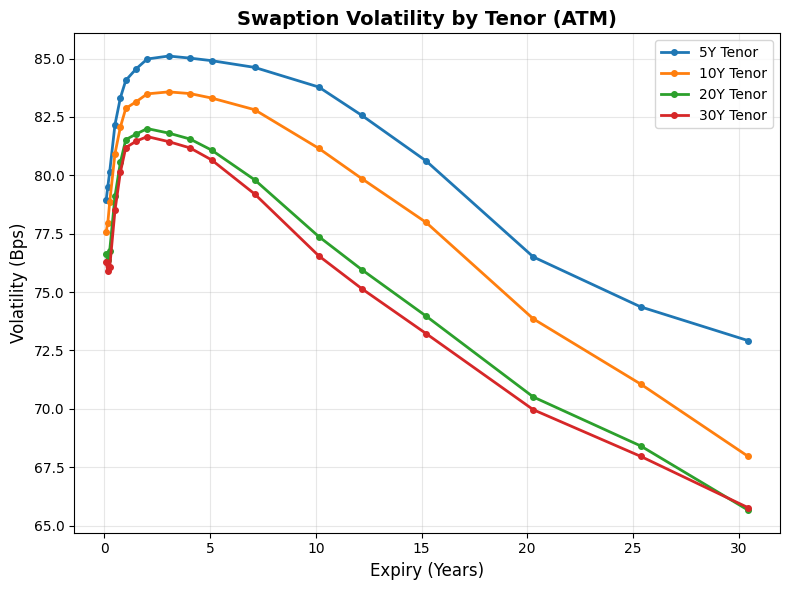

In [3]:
# Market data 
file = r'SWPN_Market_Data_30092025.xlsx'
df_mkt = pd.read_excel(file)
cube_data = create_cube(df_mkt)

# Term structure of volatilities 
moneyness = 'ATM'
key_tenors = [5.0, 10.0, 20.0, 30.0] 

plt.figure(figsize=(8, 6))

for i, tenor in enumerate(key_tenors):
    vol_matrix = cube_data[tenor]
    vols = vol_matrix[moneyness].dropna()
    year_fracs = vols.index
    plt.plot(year_fracs, vols, 'o-', linewidth=2, markersize=4, color=plt.cm.tab10(i), label=f'{int(tenor)}Y Tenor')

vols = cube_data[10.0][moneyness].dropna()
year_fracs = vols.index
mkt_term_int = interp1d(year_fracs, vols, kind='cubic', fill_value="extrapolate")

plt.title(f'Swaption Volatility by Tenor ({moneyness})', fontsize=14, fontweight='bold')
plt.xlabel('Expiry (Years)', fontsize=12)
plt.ylabel('Volatility (Bps)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

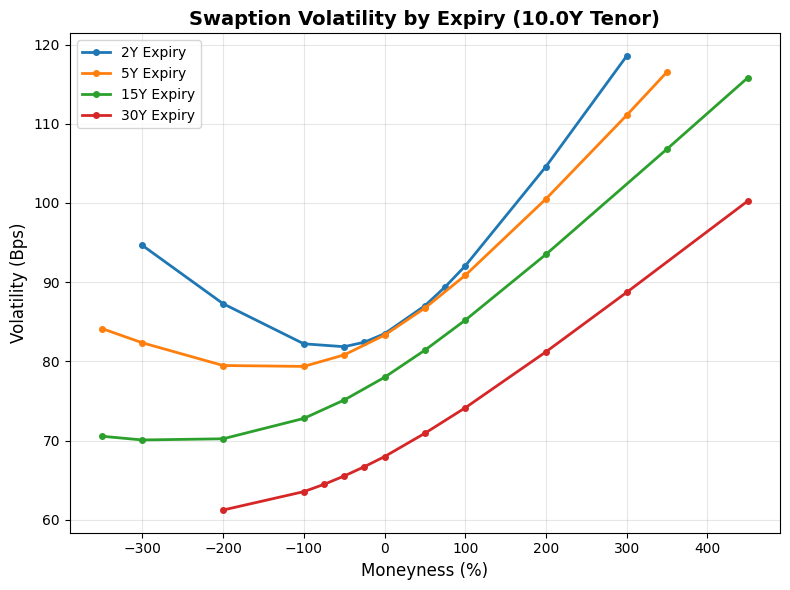

In [4]:
# Volatility smile 
tenor = 10.00
vol_matrix = cube_data[tenor]
key_expiries = [2.0, 5.0, 15.0, 30.0]

plt.figure(figsize=(8, 6))

for i, t in enumerate(key_expiries):
    mask = vol_matrix.index[np.abs(vol_matrix.index - t).argmin()]
    vols = vol_matrix.loc[mask].dropna()
    strikes = vols.index
    strikes_fix = [0.0 if K == 'ATM' else float(K) for K in strikes]
    plt.plot(strikes_fix, vols, 'o-', linewidth=2, markersize=4, color=plt.cm.tab10(i), label=f'{int(t)}Y Expiry')

plt.title(f'Swaption Volatility by Expiry ({tenor}Y Tenor)', fontsize=14, fontweight='bold')
plt.xlabel('Moneyness (%)', fontsize=12)
plt.ylabel('Volatility (Bps)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
# Discount curve data
file = r'SWPN_Calibration_Template_30092025.xlsx'
input_curve = pd.read_excel(file, sheet_name ='Curve')
time = input_curve['Year_Frac']
disc_rate = input_curve['Discount_Factor']
curve = Curve(time, disc_rate)

# Calibration data
df = pd.read_excel(file, sheet_name = 'Template')
df['Payment_Dates'] = [[float(x) for x in eval(item)] for item in df['Payment_Dates'].tolist()]

market_prices = {
    'Prices': df['Price'].tolist(),
    'Strike': df['Strike'].tolist(),
    'Notional': df['Notional'].tolist(),
    'Dates': df['Payment_Dates'].tolist()}


# Initialize pricer and calibrator, and calibrate to market
pricer = HullWhitePricer(curve)
calibrator = HullWhiteCalibrator(pricer, market_prices, calibrate_to='Swaptions', a_fixed = 0.01)
result = calibrator.calibrate()

a fixed: 0.010000, sigma: 0.008486, RMSRE: 2.66107e-02
a fixed: 0.010000, sigma: 0.008567, RMSRE: 2.46375e-02
a fixed: 0.010000, sigma: 0.008574, RMSRE: 2.46266e-02
a fixed: 0.010000, sigma: 0.008573, RMSRE: 2.46265e-02
a fixed: 0.010000, sigma: 0.008573, RMSRE: 2.46265e-02

Calibration successful:
Iterations: 5
Number of instruments: 208
Total Error:  +2.463%

Parameters:
Fixed a: 0.01000
Optimal sigma: 0.00857

Swaption   0:  1.01Y to 2.01 Y | Model:    34.05 | Market:    32.38 | Diff:  +5.183%
Swaption   1:  1.52Y to 2.52 Y | Model:    41.48 | Market:    40.51 | Diff:  +2.403%
Swaption   2:  2.03Y to 3.03 Y | Model:    47.87 | Market:    47.42 | Diff:  +0.947%
Swaption   3:  3.04Y to 4.04 Y | Model:    58.32 | Market:    58.80 | Diff:  -0.818%
Swaption   4:  4.05Y to 5.05 Y | Model:    66.94 | Market:    67.93 | Diff:  -1.449%
Swaption   5:  5.07Y to 6.07 Y | Model:    74.57 | Market:    75.84 | Diff:  -1.680%
Swaption   6:  7.10Y to 8.10 Y | Model:    87.44 | Market:    88.94 | Dif

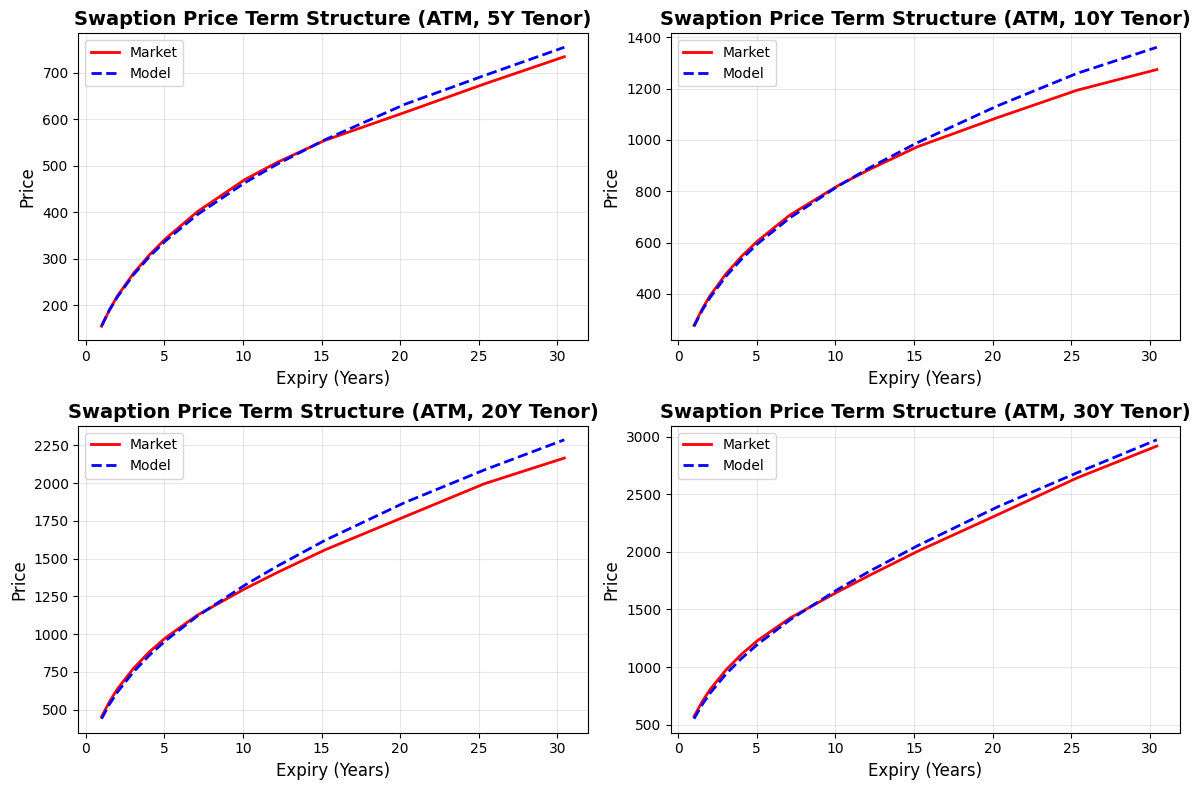

In [6]:
df['Model_Price'] = [pricer.swaption(df['Payment_Dates'][i], df['Notional'][i], df['Strike'][i]/100)/curve.discount(df['Expiry'][i]) for i in range(len(df))]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
Tenors = [5.0, 10.0, 20.0, 30.0]
axes = axes.flatten()

for idx, tenor in enumerate(Tenors):
    df_tenor = df[df['Tenor'] == tenor]
    T_vals = df_tenor['Expiry']
    model_price = df_tenor['Model_Price']
    market_price = df_tenor['Price']

    axes[idx].plot(T_vals, market_price, 'r-', linewidth=2, label='Market')
    axes[idx].plot(T_vals, model_price, 'b--', linewidth=2, label='Model')
    axes[idx].set_title(f'Swaption Price Term Structure (ATM, {int(tenor)}Y Tenor)', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Expiry (Years)', fontsize=12)
    axes[idx].set_ylabel('Price', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=10)

plt.tight_layout()
plt.show()


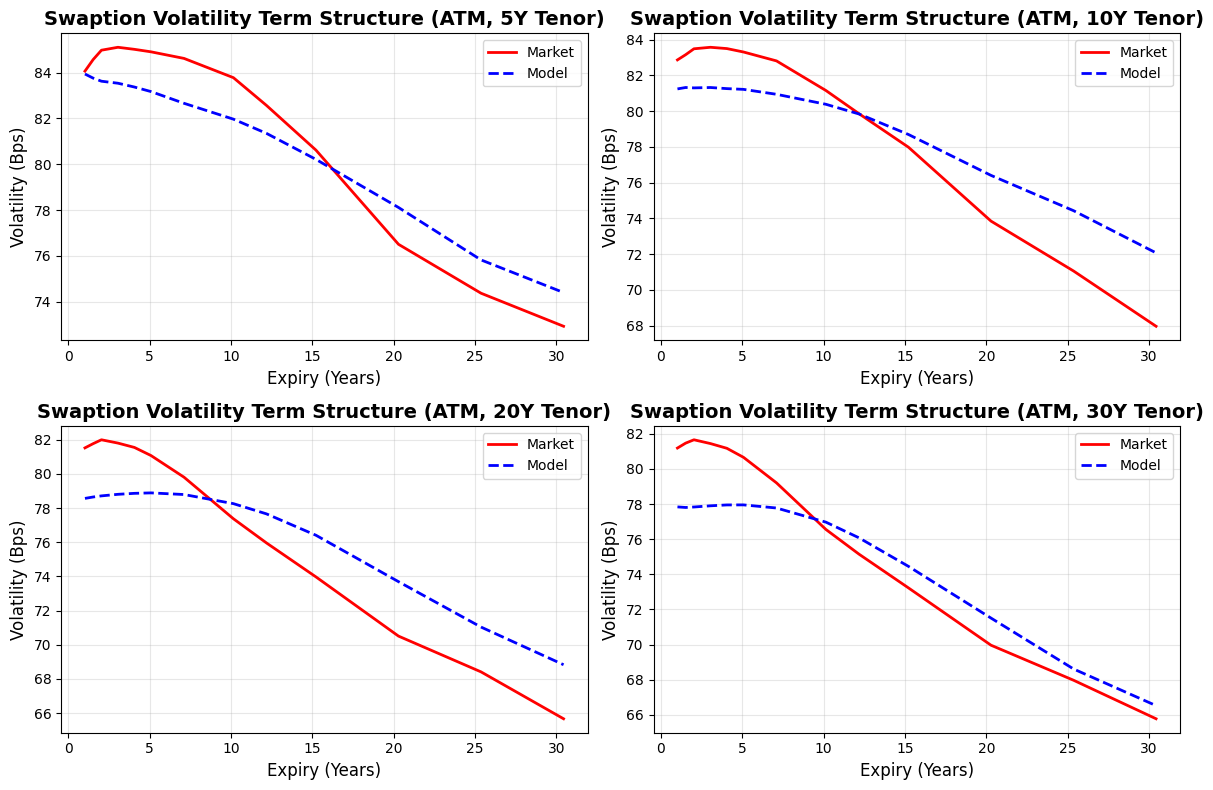

In [7]:
df['Model_Vol (Bps)'] = [black_normal_vol(df['Model_Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], df['Notional'][i], df['Duration'][i]) for i in range(len(df))]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
Tenors = [5.0, 10.0, 20.0, 30.0]
axes = axes.flatten()

for idx, tenor in enumerate(Tenors):
    df_tenor = df[df['Tenor'] == tenor]
    T_vals = df_tenor['Expiry']
    model_vol = df_tenor['Model_Vol (Bps)']
    market_vol = df_tenor['Volatility (Bps)']

    axes[idx].plot(T_vals, market_vol, 'r-', linewidth=2, label='Market')
    axes[idx].plot(T_vals, model_vol, 'b--', linewidth=2, label='Model')
    axes[idx].set_title(f'Swaption Volatility Term Structure (ATM, {int(tenor)}Y Tenor)', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Expiry (Years)', fontsize=12)
    axes[idx].set_ylabel('Volatility (Bps)', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=10)

plt.tight_layout()
plt.show()
